In [70]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from google.colab import drive
import warnings

warnings.filterwarnings('ignore')
print('Libraries imported successfully')

Libraries imported successfully


In [71]:
# Google drive connection

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
# Loading preprocessor, labels and variable names (from Notebook 03)

preprocessor = joblib.load(
    "/content/drive/MyDrive/Credit_Risk_Project/models/preprocessor.pkl"
)

feature_names = pd.read_csv(
    "/content/drive/MyDrive/Credit_Risk_Project/data/processed/feature_names.csv"
)

logistic_balanced_model = joblib.load(
    "/content/drive/MyDrive/Credit_Risk_Project/models/logistic_balanced_model.pkl"
)

In [73]:
def clean_feature_name(feature):

    feature = (
        feature
        .replace("numeric__", "")
        .replace("categorical__", "")
        .replace("binary__", "")
    )

    replacements = {
        "InterestRate": "Interest Rate",
        "LoanAmount": "Loan Amount",
        "CreditScore": "Credit Score",
        "MonthsEmployed": "Months Employed",
        "NumCreditLines": "Number of Credit Lines",
        "HasCoSigner": "Has Co-Signer",
        "HasMortgage": "Has Mortgage",
        "HasDependents": "Has Dependents",
        "EmploymentType_": "Employment: ",
        "Education_": "Education: ",
        "LoanPurpose_": "Loan Purpose: ",
        "MaritalStatus_": "Marital Status: "
    }

    for old, new in replacements.items():
        feature = feature.replace(old, new)

    return feature

In [74]:
feature_names = preprocessor.get_feature_names_out()

In [75]:
coefficients = logistic_balanced_model.coef_[0]

In [76]:
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [77]:
coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

In [78]:
coef_df.head(15)

,Feature,Coefficient
6,numeric__InterestRate,0.458580
2,numeric__LoanAmount,0.288246
15,categorical__EmploymentType_Unemployed,0.199126
9,categorical__Education_High School,0.133711
5,numeric__NumCreditLines,0.102686
20,categorical__LoanPurpose_Business,0.091138
16,categorical__MaritalStatus_Divorced,0.082256
7,numeric__DTIRatio,0.068616
8,categorical__Education_Bachelor's,0.058102
18,categorical__MaritalStatus_Single,0.030815


In [79]:
coef_df.tail(15)

,Feature,Coefficient
23,categorical__LoanPurpose_Other,0.018906
21,categorical__LoanPurpose_Education,0.017447
14,categorical__EmploymentType_Self-employed,0.008242
10,categorical__Education_Master's,-0.077604
17,categorical__MaritalStatus_Married,-0.115791
11,categorical__Education_PhD,-0.116928
3,numeric__CreditScore,-0.125108
22,categorical__LoanPurpose_Home,-0.157306
24,binary__HasMortgage,-0.164002
12,categorical__EmploymentType_Full-time,-0.239942


**FEATURE IMPORTANCE**

In [80]:
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

In [81]:
coef_importance = coef_df.sort_values(
    by="AbsCoefficient",
    ascending=False
)

In [82]:
coef_importance.head(15)

,Feature,Coefficient,AbsCoefficient
0,numeric__Age,-0.583122,0.583122
6,numeric__InterestRate,0.458580,0.458580
4,numeric__MonthsEmployed,-0.337303,0.337303
1,numeric__Income,-0.313923,0.313923
2,numeric__LoanAmount,0.288246,0.288246
26,binary__HasCoSigner,-0.258236,0.258236
25,binary__HasDependents,-0.251843,0.251843
12,categorical__EmploymentType_Full-time,-0.239942,0.239942
15,categorical__EmploymentType_Unemployed,0.199126,0.199126
24,binary__HasMortgage,-0.164002,0.164002


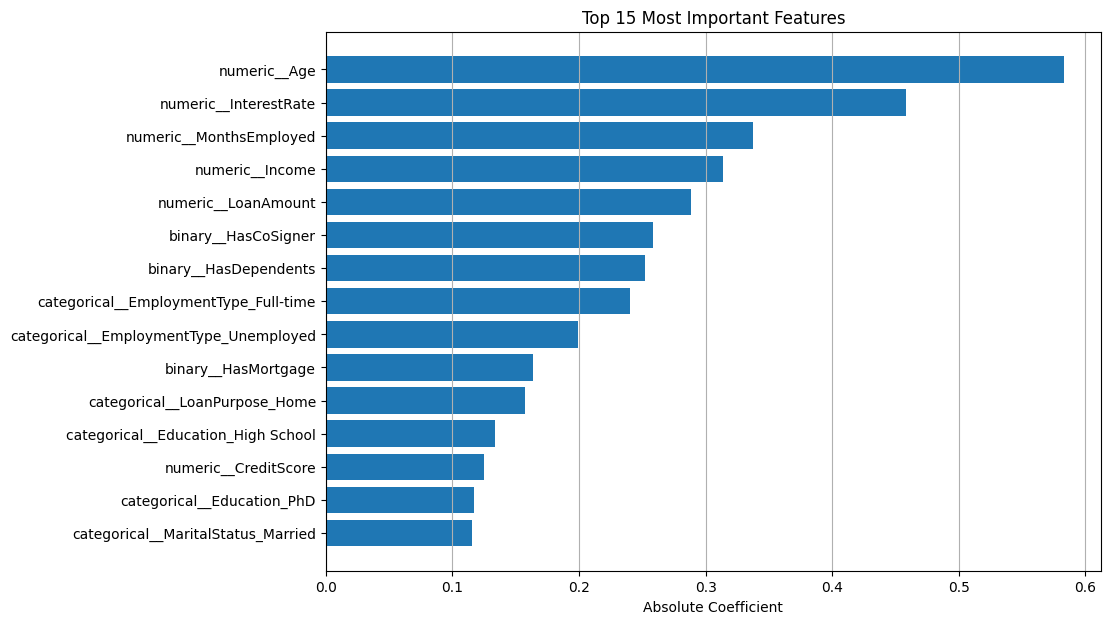

In [83]:
top_features = coef_importance.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["Feature"],
    top_features["AbsCoefficient"]
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Absolute Coefficient")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [84]:
coef_plot = coef_df.sort_values("Coefficient")

In [85]:
colors = [
    "green" if coef < 0 else "red"
    for coef in coef_plot["Coefficient"]
]

In [86]:
coef_plot["Feature"] = (
    coef_plot["Feature"]
        .str.replace("numeric__", "", regex=False)
        .str.replace("categorical__", "", regex=False)
        .str.replace("binary__", "", regex=False)
)

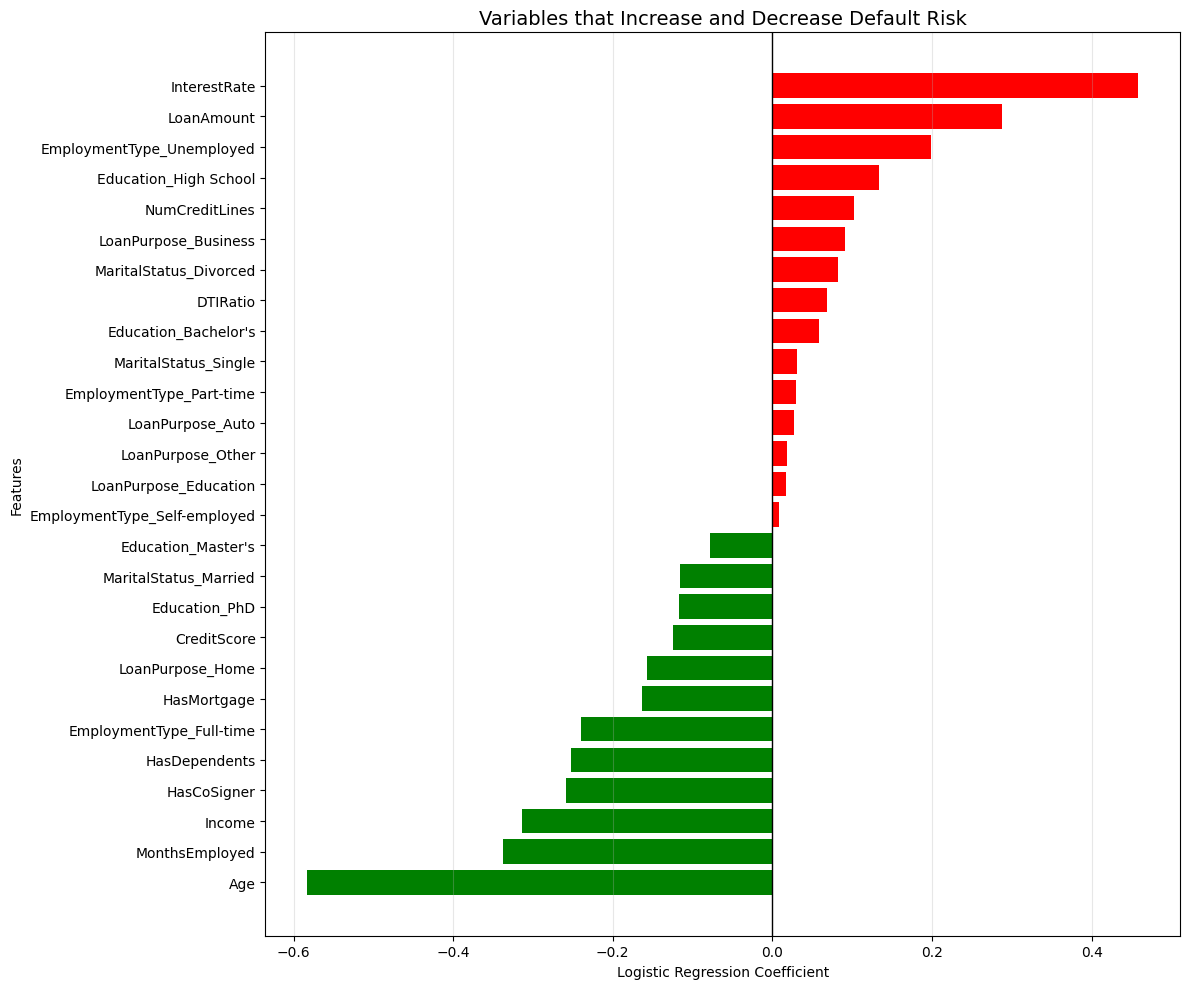

In [87]:
plt.figure(figsize=(12,10))

plt.barh(
    coef_plot["Feature"],
    coef_plot["Coefficient"],
    color=colors
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title(
    "Variables that Increase and Decrease Default Risk",
    fontsize=14
)

plt.xlabel("Logistic Regression Coefficient")

plt.ylabel("Features")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [88]:
top_positive = (
    coef_df[coef_df["Coefficient"] > 0]
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

In [89]:
top_negative = (
    coef_df[coef_df["Coefficient"] < 0]
    .sort_values("Coefficient")
    .head(10)
)

In [90]:
top_positive["Feature"] = top_positive["Feature"].apply(clean_feature_name)

top_negative["Feature"] = top_negative["Feature"].apply(clean_feature_name)

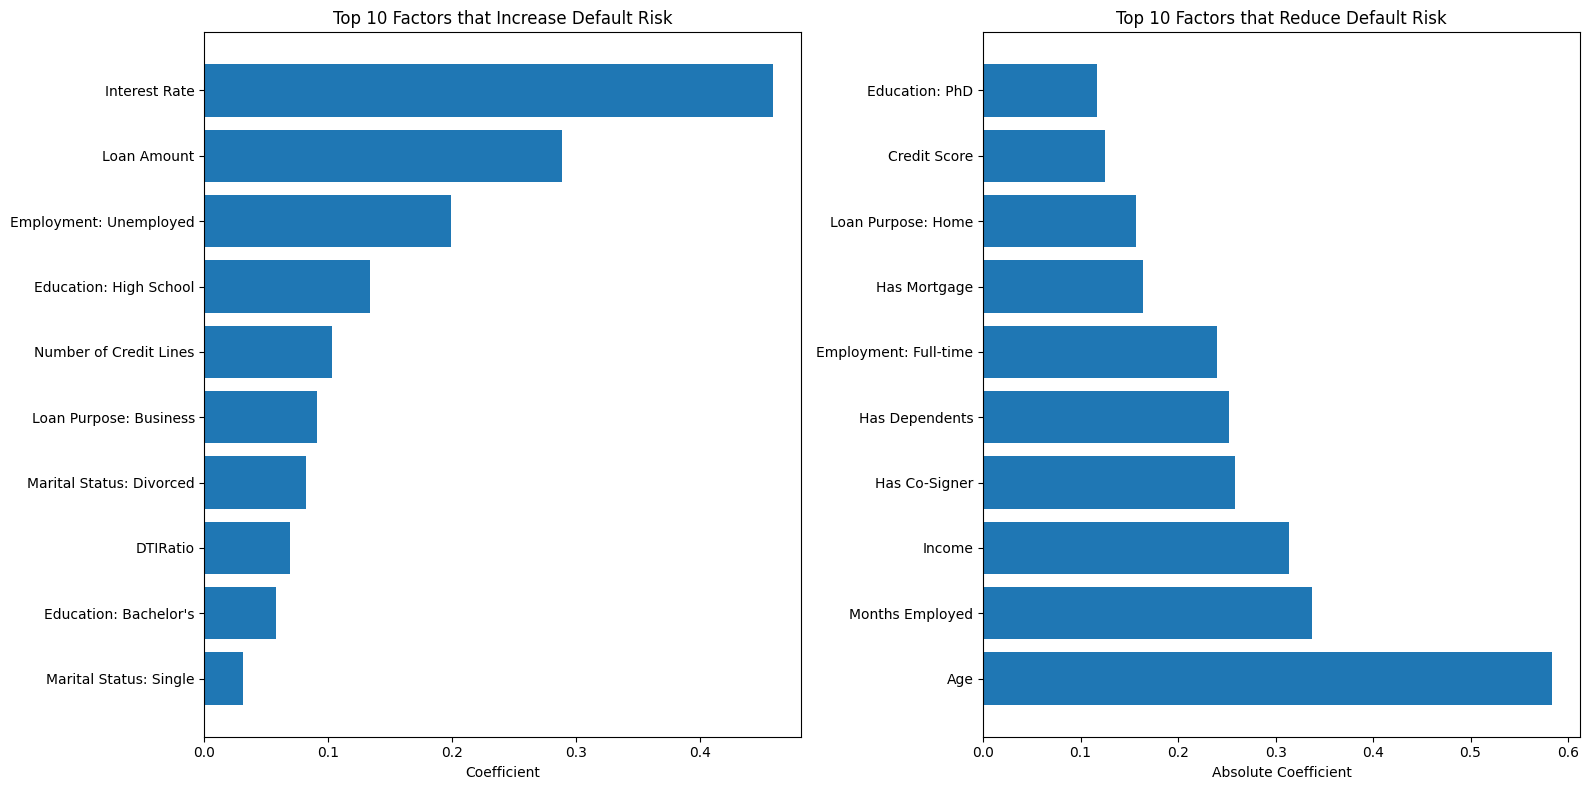

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Risk factors

axes[0].barh(
    top_positive["Feature"][::-1],
    top_positive["Coefficient"][::-1]
)

axes[0].set_title(
    "Top 10 Factors that Increase Default Risk"
)

axes[0].set_xlabel("Coefficient")

# Safe factors


axes[1].barh(
    top_negative["Feature"],
    abs(top_negative["Coefficient"])
)

axes[1].set_title(
    "Top 10 Factors that Reduce Default Risk"
)

axes[1].set_xlabel("Absolute Coefficient")
plt.tight_layout()
plt.show()